Purchase History Preview:
   order_id  customer_id order_date  order_amount product_category  \
0         1            1 2023-11-13         96.57         Clothing   
1         2            1 2022-06-14         40.05      Electronics   
2         3            1 2019-09-01         20.51             Toys   
3         4            1 2021-12-16         30.05            Books   
4         5            1 2022-11-08         13.98            Books   

   discount_used  discount_value  
0          False            0.00  
1          False            0.00  
2          False            0.00  
3           True           15.39  
4           True           45.94  

Orders per Customer Stats:
count    10000.000000
mean        10.017700
std          3.148425
min          1.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         24.000000
Name: order_id, dtype: float64

Order Amount Stats:
count    100177.000000
mean         56.823547
std          65.234966
min           4.62

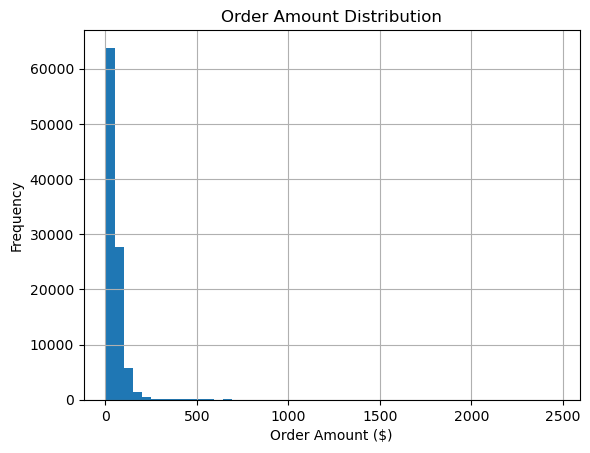

In [2]:
# Step 0: Imports and setup
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt

# Seeds for reproducibility
Faker.seed(42)
np.random.seed(42)
random.seed(42)
fake = Faker()

# -----------------------------
# Step 1: Customer Profiles (re-run inside Step 2)
# -----------------------------

num_customers = 10000

# Customer IDs
customer_ids = np.arange(1, num_customers + 1)

# Country distribution
countries = ['USA','EU','Asia','Other']
country_probs = [0.4,0.3,0.2,0.1]
customer_country = np.random.choice(countries, size=num_customers, p=country_probs)

# Names and genders
names = [fake.name() for _ in range(num_customers)]
genders = np.random.choice(['M','F','Other'], size=num_customers, p=[0.49,0.49,0.02])

# Age
ages = np.clip(np.random.normal(33, 10, num_customers), 18, 65).astype(int)

# Customer tier
tiers = ['Bronze','Silver','Gold','Platinum']
tier_probs = [0.5,0.3,0.15,0.05]
customer_tier = np.random.choice(tiers, size=num_customers, p=tier_probs)

# Signup dates with seasonality
years = np.random.choice([2019,2020,2021,2022,2023], size=num_customers)
months = np.zeros(num_customers, dtype=int)

# Probabilities per country
usa_probs  = np.array([0.05]*9 + [0.10, 0.25, 0.15]); usa_probs /= usa_probs.sum()
eu_probs   = np.array([0.05]*7 + [0.10,0.10,0.10,0.25,0.10,0.05]); eu_probs = eu_probs[:12]; eu_probs /= eu_probs.sum()
asia_probs = np.array([0.05]*10 + [0.30,0.15]); asia_probs /= asia_probs.sum()

for i, c in enumerate(customer_country):
    if c=='USA':
        months[i] = np.random.choice(np.arange(1,13), p=usa_probs)
    elif c=='EU':
        months[i] = np.random.choice(np.arange(1,13), p=eu_probs)
    elif c=='Asia':
        months[i] = np.random.choice(np.arange(1,13), p=asia_probs)
    else:
        months[i] = np.random.randint(1,13)

days = np.random.randint(1,29, size=num_customers)
signup_dates = pd.to_datetime(dict(year=years, month=months, day=days))

# Assemble DataFrame
customer_profiles = pd.DataFrame({
    'customer_id': customer_ids,
    'name': names,
    'gender': genders,
    'age': ages,
    'country': customer_country,
    'signup_date': signup_dates,
    'customer_tier': customer_tier
})

# -----------------------------
# Step 2: Purchase History
# -----------------------------

avg_orders_per_customer = 10
order_multiplier = np.random.poisson(lam=avg_orders_per_customer, size=num_customers)

orders_list = []
order_id_counter = 1
product_categories = ['Electronics','Clothing','Home','Books','Toys','Beauty','Sports','Grocery','Automotive','Jewelry']

for idx, customer_id in enumerate(customer_profiles['customer_id']):
    num_orders = max(1, order_multiplier[idx])
    country = customer_profiles.loc[idx, 'country']
    tier = customer_profiles.loc[idx, 'customer_tier']
    
    for _ in range(num_orders):
        # Year and Month
        year = np.random.choice([2019,2020,2021,2022,2023])
        if country=='USA':
            month_probs = np.array([0.05]*9 + [0.10,0.25,0.15]); month_probs /= month_probs.sum()
        elif country=='EU':
            month_probs = np.array([0.05]*7 + [0.10,0.10,0.10,0.25,0.10,0.05]); month_probs=month_probs[:12]; month_probs/=month_probs.sum()
        elif country=='Asia':
            month_probs = np.array([0.05]*10 + [0.30,0.15]); month_probs/=month_probs.sum()
        else:
            month_probs = np.ones(12)/12
        
        month = np.random.choice(np.arange(1,13), p=month_probs)
        day = np.random.randint(1,29)
        order_date = pd.Timestamp(year=year, month=month, day=day)
        
        # Order amount with tier
        tier_factor = {'Bronze':1,'Silver':1.5,'Gold':2,'Platinum':3}[tier]
        order_amount = np.random.lognormal(mean=3.5, sigma=0.5)*tier_factor
        if np.random.rand()<0.01:  # rare outlier
            order_amount*=10
        
        # Category & discount
        product_category = random.choice(product_categories)
        discount_used = np.random.rand()<0.35
        discount_value = np.random.uniform(5,50) if discount_used else 0
        
        # Append
        orders_list.append({
            'order_id': order_id_counter,
            'customer_id': customer_id,
            'order_date': order_date,
            'order_amount': round(order_amount,2),
            'product_category': product_category,
            'discount_used': discount_used,
            'discount_value': round(discount_value,2)
        })
        order_id_counter+=1

purchase_history = pd.DataFrame(orders_list)

# -----------------------------
# Step 3: Validation
# -----------------------------
print("Purchase History Preview:")
print(purchase_history.head())

print("\nOrders per Customer Stats:")
print(purchase_history.groupby('customer_id')['order_id'].count().describe())

print("\nOrder Amount Stats:")
print(purchase_history['order_amount'].describe())

purchase_history['order_amount'].hist(bins=50)
plt.title("Order Amount Distribution")
plt.xlabel("Order Amount ($)")
plt.ylabel("Frequency")
plt.show()

In [3]:
purchase_history.to_csv('../data/purchase_history_10k.csv', index=False)
print("purchase_history_10k.csv saved!")

purchase_history_10k.csv saved!
